In [126]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest

## Test1

In [127]:
strategies = [
    ('Momentum', momentum_strategy, 'mom', None, None),
    ('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

In [128]:
assets = ['AAPL']


[*********************100%***********************]  1 of 1 completed

AAPL
Momentum
Market Sharpe Ratio: 0.9056
Best Momentum Strategy window: 14
Best Sharpe ratio: 1.4170

Mean Reversion


Market Sharpe Ratio: 0.9056
Best Mean Reversion Strategy window: 4
Best threshold: 2%
Best Sharpe ratio: 1.0283

Momentum + Trend Strength
Market Sharpe Ratio: 0.9056
Best Momentum + Trend Strength Strategy window: 10
Best Sharpe ratio: 1.1971

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.9056
Best Momentum + Rolling Volatility Strategy window: 14
Best threshold: 2%
Best Sharpe ratio: 1.6868

Momentum + Volume Ratio
Market Sharpe Ratio: 0.9056
Best Momentum + Volume Ratio Strategy window: 20
Best Sharpe ratio: 1.2302

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


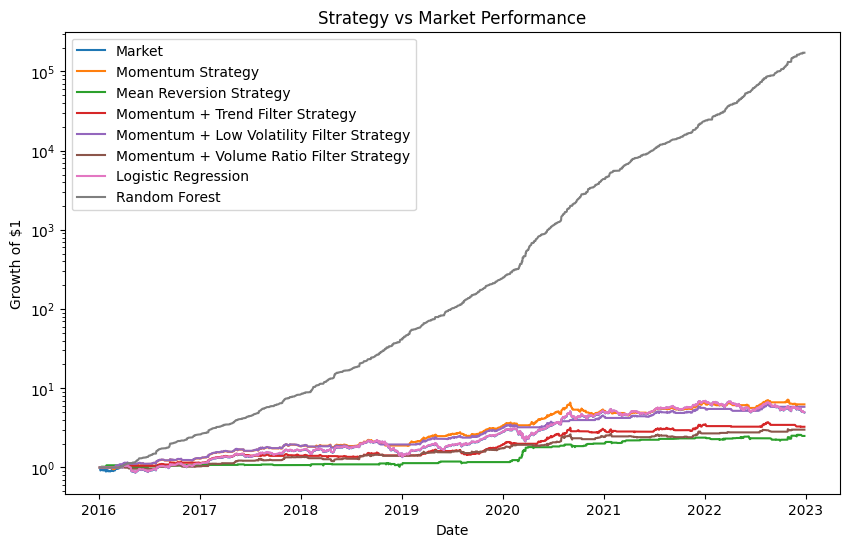

Testing Performance


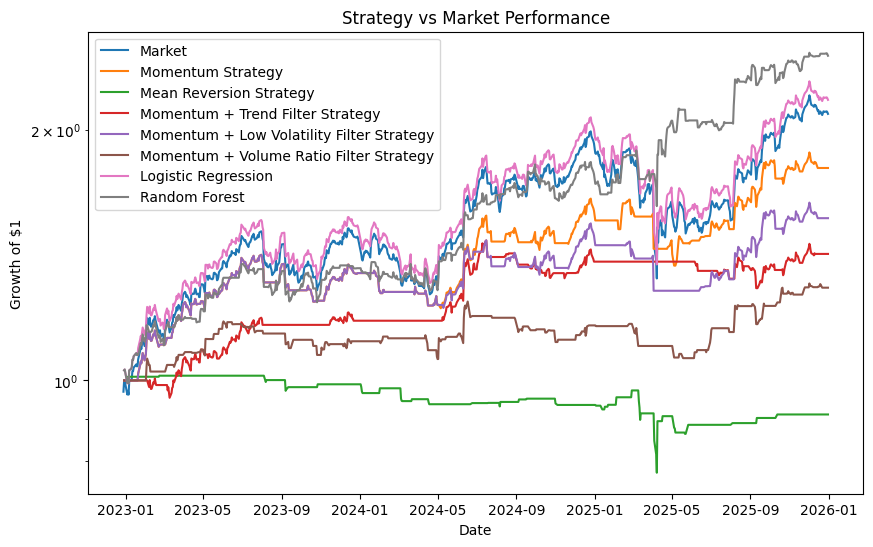


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.905573    0.303760 -0.387297   
1                       Momentum  1.416952    0.199519 -0.313157   
2                 Mean Reversion  1.028301    0.136398 -0.118219   
3      Momentum + Trend Strength  1.197057    0.151061 -0.144578   
4  Momentum + Rolling Volatility  1.686844    0.157121 -0.118903   
5        Momentum + Volume Ratio  1.230180    0.135403 -0.141400   
6            Logistic Regression  0.918925    0.298881 -0.387297   
7                  Random Forest  9.242371    0.189493  0.000000   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.525867          0.543907       0.651288        63.445139  
2         0.484935          0.585526       0.095494         8.641273  
3         0.509380          0.545575       0.443133        43.035816  
4         0.52

In [129]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    windows=range(2, 50, 2),
    logscale=True
)

## Test 2

In [130]:
strategies = [
    #('Momentum', momentum_strategy, 'mom', None, None),
    #('Mean Reversion', mean_reversion_strategy, 'mr', range(2, 100, 2), None),
    #("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    #("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    #("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

In [131]:
#assets = ['AAPL', 'MSFT','SPY','NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']
assets = ['LVMUY']

LVMUY


[*********************100%***********************]  1 of 1 completed

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...


Random Forest model trained and tested.

Training Performance


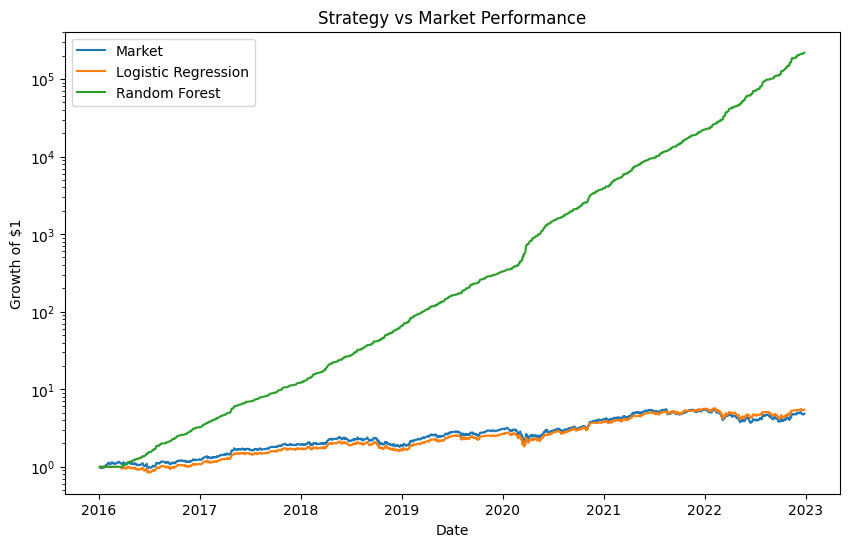

Testing Performance


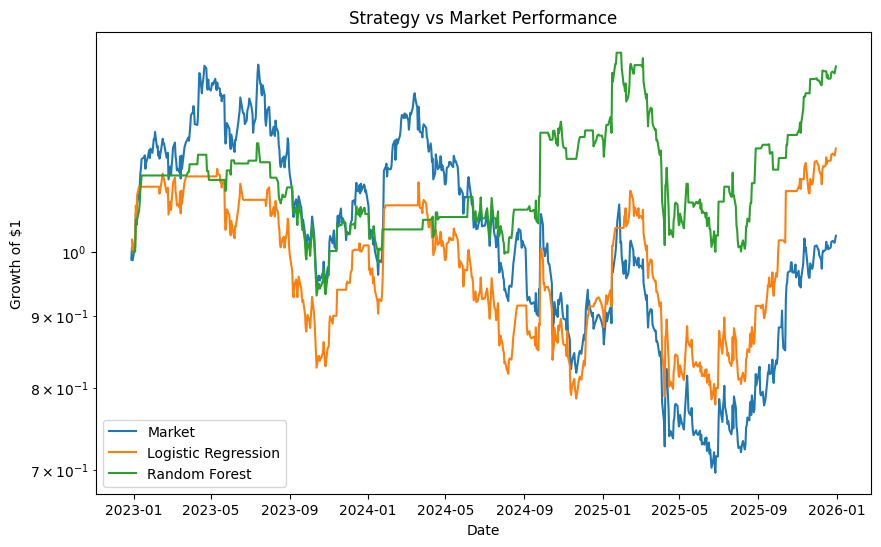


Training Results
              Strategy    Sharpe  Volatility    Max DD  Signal Accuracy  \
0               Market  0.894558    0.304414 -0.356761              NaN   
1  Logistic Regression  0.989644    0.287570 -0.335424         0.529847   
2        Random Forest  9.543060    0.187014  0.000000         0.982945   

   Signal Precision  Signal Recall  Signal Active %  
0               NaN            NaN              NaN  
1          0.537196       0.868085        86.355884  
2          1.000000       0.968085        51.733940  

Testing Results
              Strategy    Sharpe  Volatility    Max DD  Signal Accuracy  \
0               Market  0.180362    0.306474 -0.487399              NaN   
1  Logistic Regression  0.340527    0.277559 -0.320103         0.490066   
2        Random Forest  0.569142    0.219947 -0.278265         0.509934   

   Signal Precision  Signal Recall  Signal Active %  
0               NaN            NaN              NaN  
1          0.501786       0.726098     

In [132]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    feature_set='v2',
    windows=range(2, 50, 2),
    logscale=True,
    save_csv=False
)

## Analysis between feature sets

In [133]:
strategy = [
    'Logistic Regression',
    'Random Forest'
]
df = pd.read_csv("../outputs/experiment_results.csv")
df = df[df['Strategy'].isin(strategy)]

<Figure size 1000x500 with 0 Axes>

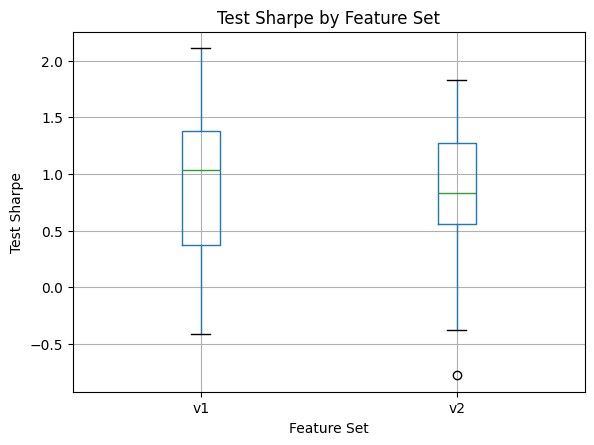

In [134]:
plt.figure(figsize=(10,5))

df.boxplot(
    column="Test Sharpe",
    by="Feature Set",
    rot=0
)

plt.title("Test Sharpe by Feature Set")
plt.suptitle("")
plt.ylabel("Test Sharpe")

plt.show()

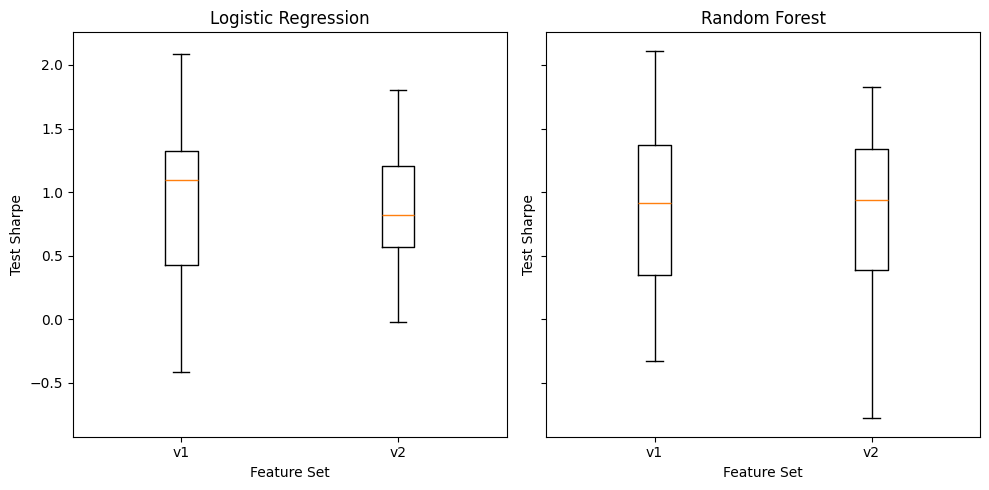

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(10,5), sharey=True)

for ax, strategy in zip(axes, ["Logistic Regression", "Random Forest"]):

    subset = df[df["Strategy"] == strategy]

    data = [
        subset.loc[subset["Feature Set"] == "v1", "Test Sharpe"].dropna(),
        subset.loc[subset["Feature Set"] == "v2", "Test Sharpe"].dropna()
    ]

    ax.boxplot(data, tick_labels=["v1", "v2"])

    ax.set_title(strategy)
    ax.set_xlabel("Feature Set")
    ax.set_ylabel("Test Sharpe")

plt.tight_layout()
plt.show()

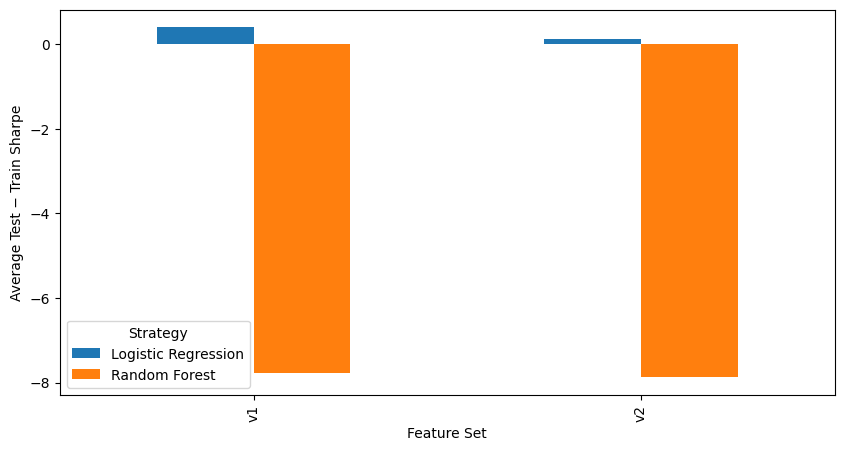

In [136]:
df["Sharpe Decay"] = (
    df["Test Sharpe"] -
    df["Train Sharpe"]
)

summary = (
    df.groupby(["Feature Set","Strategy"])
      ["Sharpe Decay"]
      .mean()
      .unstack()
)

summary.plot.bar(figsize=(10,5))

plt.ylabel("Average Test − Train Sharpe")

plt.show()

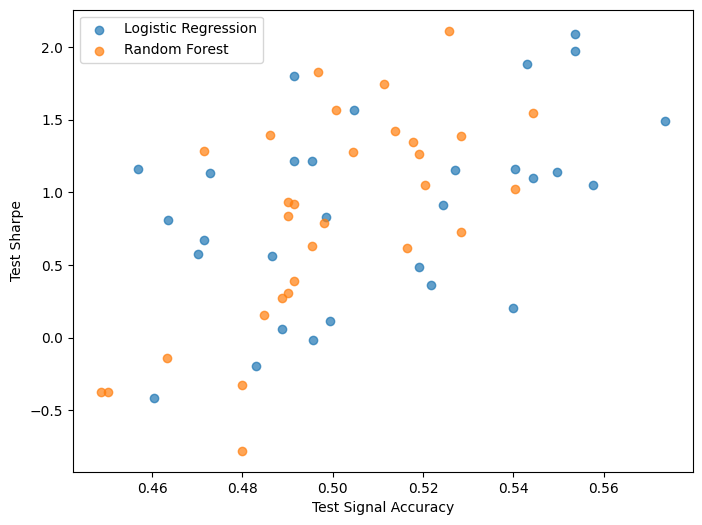

In [137]:
plt.figure(figsize=(8,6))

for strategy in df["Strategy"].unique():

    subset = df[df["Strategy"] == strategy]

    plt.scatter(
        subset["Test Signal Accuracy"],
        subset["Test Sharpe"],
        label=strategy,
        alpha=.7
    )

plt.xlabel("Test Signal Accuracy")
plt.ylabel("Test Sharpe")

plt.legend()

plt.show()

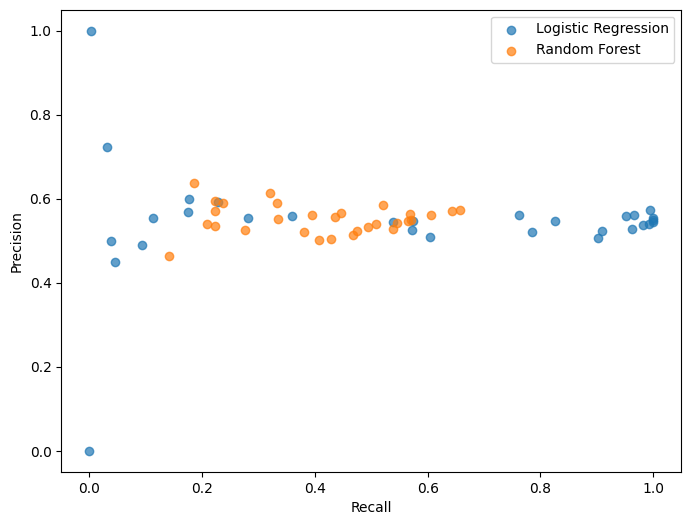

In [138]:
plt.figure(figsize=(8,6))

for strategy in df["Strategy"].unique():

    subset = df[df["Strategy"] == strategy]

    plt.scatter(
        subset["Test Signal Recall"],
        subset["Test Signal Precision"],
        label=strategy,
        alpha=.7
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.show()

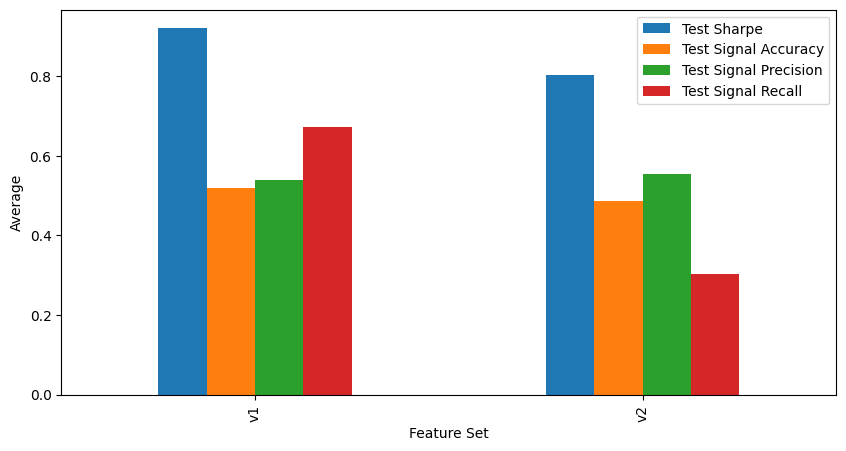

In [139]:
summary = (
    df.groupby("Feature Set")
      [["Test Sharpe",
        "Test Signal Accuracy",
        "Test Signal Precision",
        "Test Signal Recall"]]
      .mean()
)

summary.plot.bar(figsize=(10,5))

plt.ylabel("Average")

plt.show()

In [140]:
summary = (
    df.groupby(["Feature Set","Strategy"])
      [["Test Sharpe",
        "Test Signal Accuracy",
        "Test Signal Precision",
        "Test Signal Recall"]]
      .mean()
      .round(3)
)

summary

Test Sharpe  Test Signal Accuracy  \
Feature Set Strategy                                                 
v1          Logistic Regression        0.960                 0.533   
            Random Forest              0.882                 0.507   
v2          Logistic Regression        0.836                 0.481   
            Random Forest              0.774                 0.491   

                                 Test Signal Precision  Test Signal Recall  
Feature Set Strategy                                                        
v1          Logistic Regression                  0.536               0.814  
            Random Forest                        0.544               0.529  
v2          Logistic Regression                  0.551               0.310  
            Random Forest                        0.559               0.295

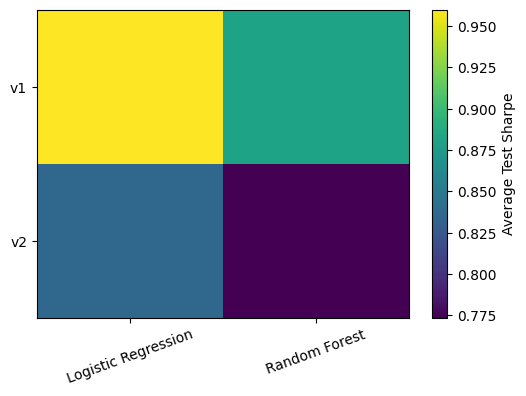

In [141]:
pivot = df.pivot_table(
    values="Test Sharpe",
    index="Feature Set",
    columns="Strategy",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))

plt.imshow(
    pivot,
    aspect="auto"
)

plt.colorbar(label="Average Test Sharpe")

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=20
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.show()

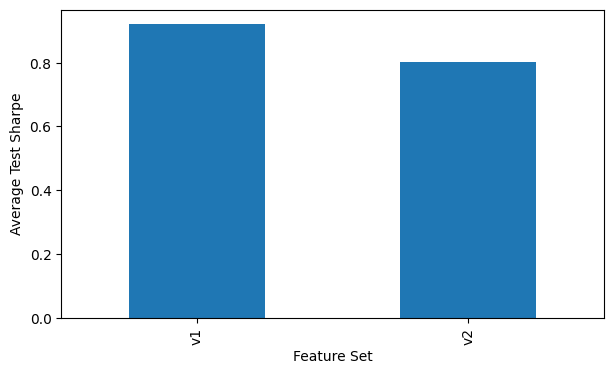

In [142]:
ranking = (
    df.groupby("Feature Set")
      ["Test Sharpe"]
      .mean()
      .sort_values(ascending=False)
)

ranking.plot.bar(figsize=(7,4))

plt.ylabel("Average Test Sharpe")

plt.show()

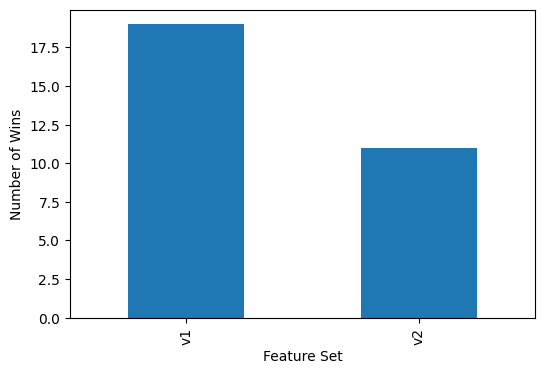

In [143]:
wins = (
    df.loc[
        df.groupby(["Asset","Strategy"])["Test Sharpe"].idxmax()
    ]
)

wins["Feature Set"].value_counts().plot.bar(figsize=(6,4))

plt.ylabel("Number of Wins")

plt.show()

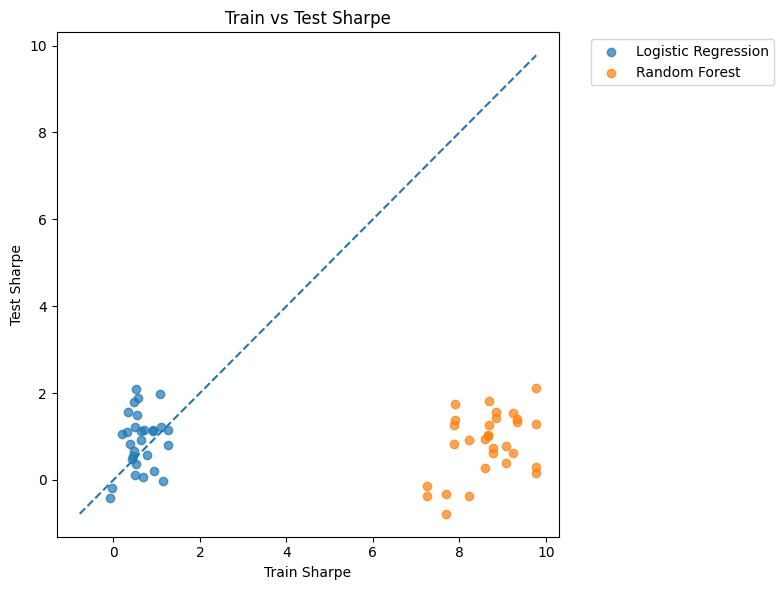

In [144]:
plt.figure(figsize=(8,6))

for strategy in df["Strategy"].unique():

    subset = df[df["Strategy"] == strategy]

    plt.scatter(
        subset["Train Sharpe"],
        subset["Test Sharpe"],
        label=strategy,
        alpha=0.7
    )

lims = [
    min(df["Train Sharpe"].min(), df["Test Sharpe"].min()),
    max(df["Train Sharpe"].max(), df["Test Sharpe"].max())
]

plt.plot(lims, lims, "--")

plt.xlabel("Train Sharpe")
plt.ylabel("Test Sharpe")
plt.title("Train vs Test Sharpe")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.show()

In [145]:
df["Sharpe Ratio"] = np.where(
    df["Train Sharpe"] != 0,
    df["Test Sharpe"] / df["Train Sharpe"],
    np.nan
)

In [146]:
summary = (
    df.groupby("Strategy")
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",
          "Train Volatility":"mean",
          "Test Volatility":"mean",
          "Train Max DD":"mean",
          "Test Max DD":"mean",
          "Train Signal Accuracy":"mean",
          "Test Signal Accuracy":"mean",
          "Train Signal Precision":"mean",
          "Test Signal Precision":"mean",
          "Train Signal Recall":"mean",
          "Test Signal Recall":"mean",
          "Train Signal Active %":"mean",
          "Test Signal Active %":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,Train Sharpe,Test Sharpe,Train Volatility,Test Volatility,Train Max DD,Test Max DD,Train Signal Accuracy,Test Signal Accuracy,Train Signal Precision,Test Signal Precision,Train Signal Recall,Test Signal Recall,Train Signal Active %,Test Signal Active %
Strategy,,,,,,,,,,,,,,
Logistic Regression,0.633086,0.900300,0.291169,0.191574,-0.40037,-0.206873,0.528143,0.507068,0.529558,0.543946,0.767943,0.562216,75.889965,56.118362
Random Forest,8.645609,0.827776,0.248711,0.225066,0.00000,-0.246249,0.983202,0.498955,1.000000,0.551606,0.967308,0.411852,50.171898,40.536693


## Cross-Asset Testing

In [147]:
strategy = [
    'Momentum',
    'Mean Reversion',
    'Momentum + Trend Strength',
    'Momentum + Rolling Volatility',
    'Momentum + Volume Ratio',
    'Logistic Regression',
    'Random Forest'
]
assets = ['AAPL', 'NVDA', 'JPM', 'XOM', 'JNJ']

featureversion = [None, 'v1']

df = pd.read_csv("../outputs/experiment_results.csv")
df = df[df['Strategy'].isin(strategy)]
df = df[df['Asset'].isin(assets)]

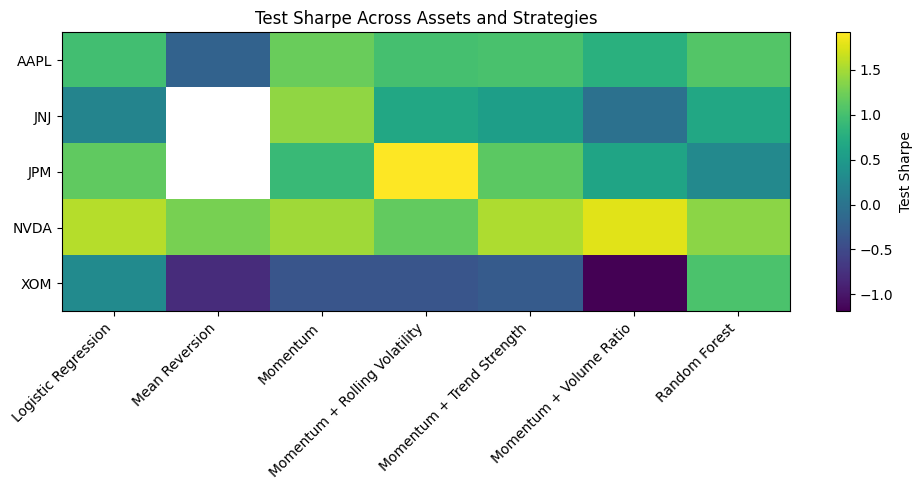

In [149]:
pivot = df.pivot_table(
    values="Test Sharpe",
    index="Asset",
    columns="Strategy",
    aggfunc="mean"
)

plt.figure(figsize=(10,5))

plt.imshow(pivot, aspect="auto")

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.colorbar(label="Test Sharpe")

plt.title("Test Sharpe Across Assets and Strategies")

plt.tight_layout()
plt.show()

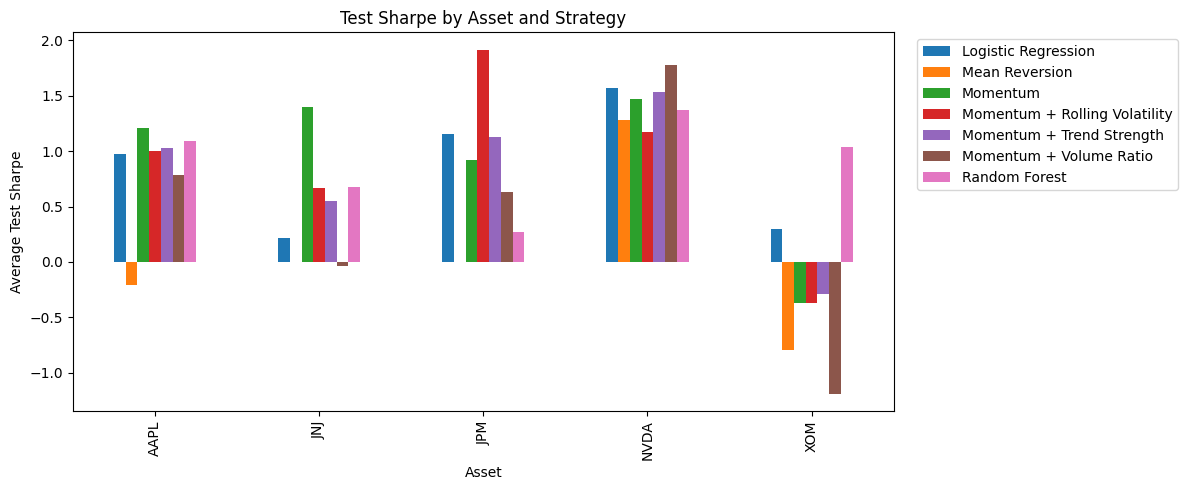

In [150]:
summary = (
    df.groupby(["Asset","Strategy"])["Test Sharpe"]
      .mean()
      .unstack()
)

summary.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Test Sharpe")
plt.title("Test Sharpe by Asset and Strategy")
plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

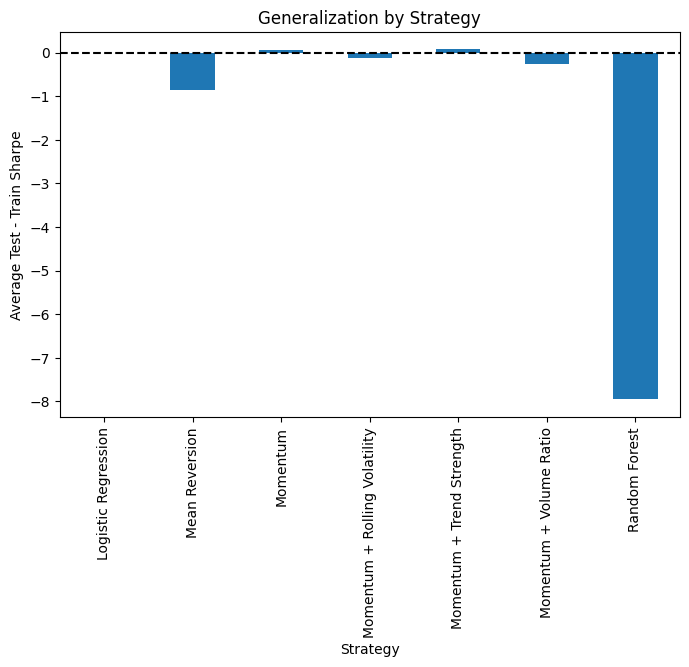

In [151]:
df["Sharpe Decay"] = (
    df["Test Sharpe"] -
    df["Train Sharpe"]
)

summary = (
    df.groupby("Strategy")["Sharpe Decay"]
      .mean()
)

summary.plot.bar(figsize=(8,5))

plt.axhline(0,color="black",linestyle="--")
plt.ylabel("Average Test - Train Sharpe")
plt.title("Generalization by Strategy")

plt.show()

<Figure size 800x500 with 0 Axes>

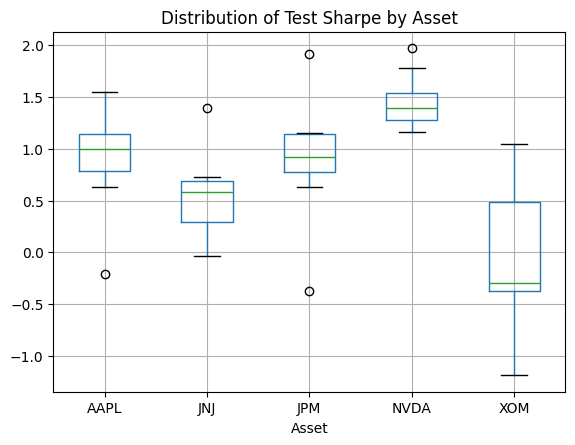

In [152]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="Test Sharpe",
    by="Asset",
    rot=0
)

plt.suptitle("")
plt.title("Distribution of Test Sharpe by Asset")

plt.show()

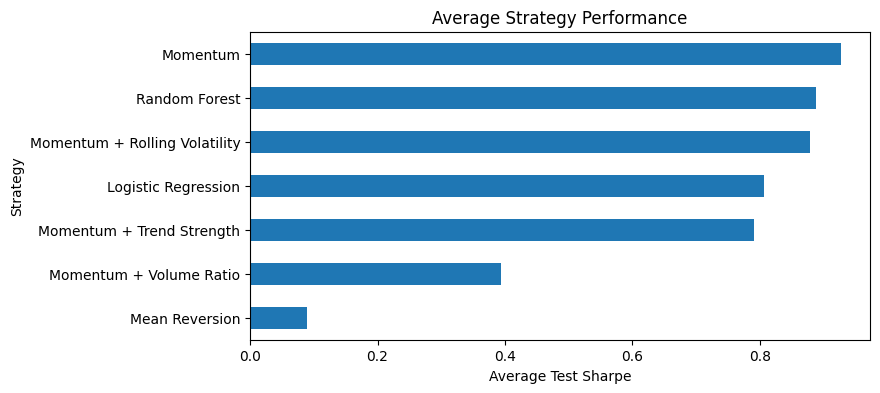

In [153]:
ranking = (
    df.groupby("Strategy")["Test Sharpe"]
      .mean()
      .sort_values()
)

ranking.plot.barh(figsize=(8,4))

plt.xlabel("Average Test Sharpe")
plt.title("Average Strategy Performance")

plt.show()

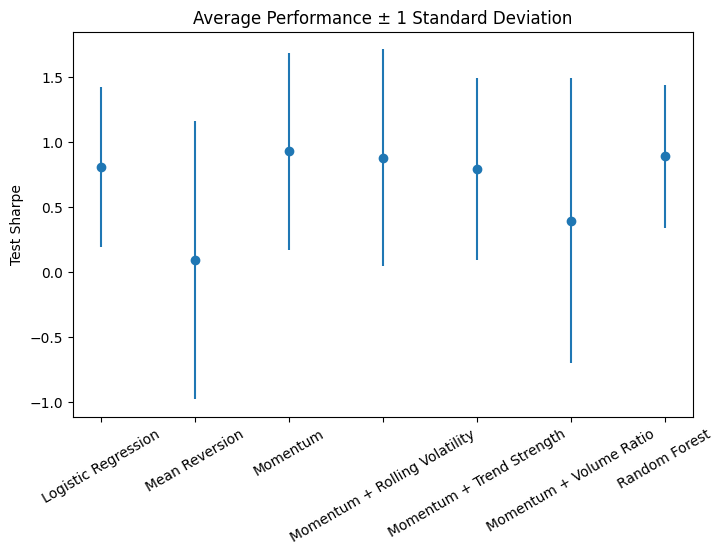

In [154]:
summary = (
    df.groupby("Strategy")["Test Sharpe"]
      .agg(["mean","std"])
)

plt.figure(figsize=(8,5))

plt.errorbar(
    summary.index,
    summary["mean"],
    yerr=summary["std"],
    fmt="o"
)

plt.xticks(rotation=30)

plt.ylabel("Test Sharpe")

plt.title("Average Performance ± 1 Standard Deviation")

plt.show()

In [157]:
summary = (
    df.groupby(["Strategy", "Feature Set"], dropna=False)
      .agg({
          "Train Sharpe":"mean",
          "Test Sharpe":"mean",

          "Train Volatility":"mean",
          "Test Volatility":"mean",

          "Train Max DD":"mean",
          "Test Max DD":"mean",

          "Train Signal Accuracy":"mean",
          "Test Signal Accuracy":"mean",

          "Train Signal Precision":"mean",
          "Test Signal Precision":"mean",

          "Train Signal Recall":"mean",
          "Test Signal Recall":"mean",

          "Train Signal Active %":"mean",
          "Test Signal Active %":"mean"
      })
      .sort_values(
          "Test Sharpe",
          ascending=False
      )
)

summary

,,Train Sharpe,Test Sharpe,Train Volatility,Test Volatility,Train Max DD,Test Max DD,Train Signal Accuracy,Test Signal Accuracy,Train Signal Precision,Test Signal Precision,Train Signal Recall,Test Signal Recall,Train Signal Active %,Test Signal Active %
Strategy,Feature Set,,,,,,,,,,,,,,
Random Forest,v1,8.847629,1.111764,0.199421,0.205700,0.000000,-0.215808,0.985219,0.524503,1.000000,0.559621,0.971527,0.561717,50.437749,54.119205
Logistic Regression,v1,0.733860,1.023085,0.289311,0.261710,-0.407937,-0.272171,0.519727,0.534305,0.520953,0.541540,0.873861,0.891057,87.117681,88.900662
Momentum,NaN,0.854698,0.926389,0.208592,0.198040,-0.288482,-0.218114,0.512678,0.522649,0.526378,0.551198,0.604965,0.606818,59.693007,59.602649
Momentum + Rolling Volatility,NaN,0.993161,0.878002,0.194346,0.192424,-0.223268,-0.220783,0.515179,0.514172,0.532101,0.547823,0.554324,0.560134,54.144400,55.258278
Momentum + Trend Strength,NaN,0.718510,0.791053,0.180401,0.168295,-0.269957,-0.181605,0.503354,0.499073,0.523425,0.541395,0.444637,0.454558,44.161455,45.430464
Random Forest,v2,8.847629,0.664125,0.199421,0.151816,0.000000,-0.180186,0.985219,0.493775,1.000000,0.571082,0.971527,0.294517,50.437749,28.052980
Logistic Regression,v2,0.897423,0.537037,0.267046,0.101068,-0.344861,-0.107221,0.528368,0.468344,0.530456,0.457905,0.750140,0.330048,73.450824,33.350993
Momentum + Volume Ratio,NaN,0.645091,0.393459,0.149452,0.141488,-0.217383,-0.197122,0.499034,0.479205,0.538816,0.538925,0.231794,0.226051,22.330870,22.569536
Mean Reversion,NaN,0.848007,0.089928,0.091881,0.047545,-0.065676,-0.057242,0.487209,0.460927,0.786550,0.277959,0.028592,0.015900,2.387720,1.615894
